# 🌏 Fuzzy Logic – Earthquake Magnitude Prediction
**Course:** DKA Tugas Besar | **Dataset:** Japan Earthquakes 2001–2018

This notebook tests the fuzzy logic system implemented in `fuzzy_system.py`.
It covers:
1. Fuzzification demo
2. Single-row prediction (Mamdani & Sugeno)
3. Batch evaluation with error metrics
4. Comparison: Mamdani vs. Sugeno
5. Interactive custom input tester

---
## Cell 1 – Import the fuzzy system module

In [1]:
# Make sure we can import from the same folder
import sys, os
sys.path.insert(0, os.getcwd())

from fuzzy_system import (
    trimf, trapmf,
    fuzzify_row,
    fuzzify_latitude, fuzzify_longitude, fuzzify_depth, fuzzify_gap, fuzzify_rms,
    RULES, SUGENO_CONSTANTS,
    mamdani_inference, mamdani_aggregate,
    sugeno_inference,
    defuzzify_mamdani_cog, defuzzify_sugeno_weighted_avg,
    mu_output,
    predict,
    evaluate_all,
    CLEAN_CSV
)
print('Import successful!')
print(f'Total rules in rule base: {len(RULES)}')

Import successful!
Total rules in rule base: 25


---
## Cell 2 – Visualise all Membership Functions

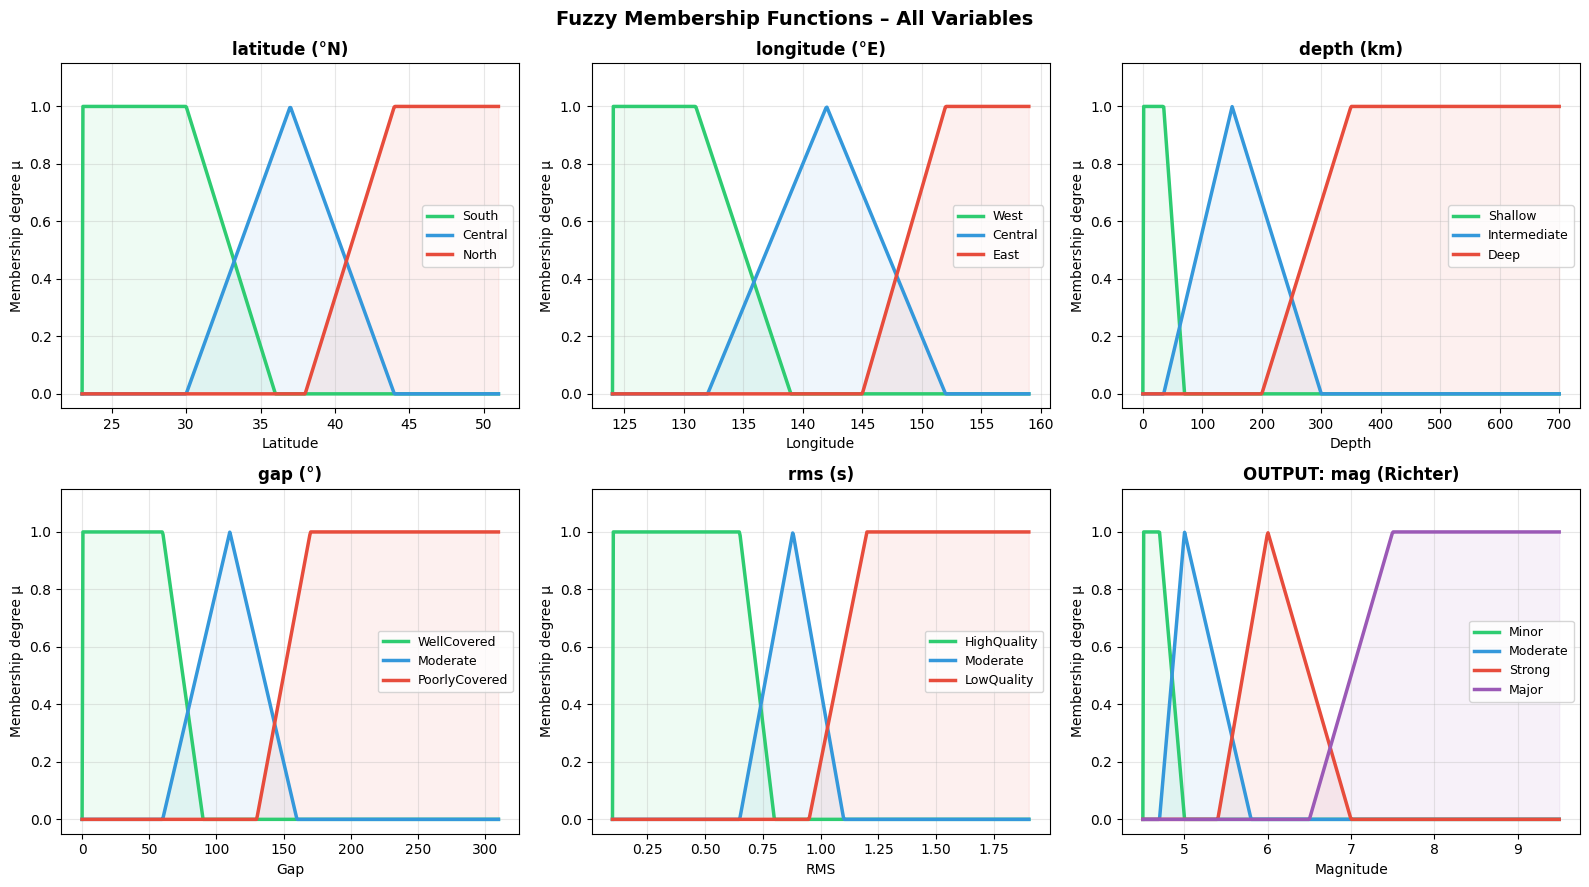

Saved → mf_plots.png


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ── helper ────────────────────────────────────────────────────────────────────
def plot_mfs(ax, universe, mf_dict, title, xlabel):
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
    for (label, fn), color in zip(mf_dict.items(), colors):
        ys = [fn(x) for x in universe]
        ax.plot(universe, ys, label=label, color=color, linewidth=2.5)
        # shade under curve
        ax.fill_between(universe, ys, alpha=0.08, color=color)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Membership degree μ')
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Fuzzy Membership Functions – All Variables', fontsize=14, fontweight='bold')

# latitude
lat_u = np.linspace(23, 51, 500)
plot_mfs(axes[0,0], lat_u,
    {'South':   lambda x: trapmf(x, 23, 23, 30, 36),
     'Central': lambda x: trimf (x, 30, 37, 44),
     'North':   lambda x: trapmf(x, 38, 44, 51, 51)},
    'latitude (°N)', 'Latitude')

# longitude
lon_u = np.linspace(124, 159, 500)
plot_mfs(axes[0,1], lon_u,
    {'West':    lambda x: trapmf(x, 124, 124, 131, 139),
     'Central': lambda x: trimf (x, 132, 142, 152),
     'East':    lambda x: trapmf(x, 145, 152, 159, 159)},
    'longitude (°E)', 'Longitude')

# depth
dep_u = np.linspace(0, 700, 500)
plot_mfs(axes[0,2], dep_u,
    {'Shallow':      lambda x: trapmf(x,   0,   0,  35,  70),
     'Intermediate': lambda x: trimf (x,  35, 150, 300),
     'Deep':         lambda x: trapmf(x, 200, 350, 700, 700)},
    'depth (km)', 'Depth')

# gap
gap_u = np.linspace(0, 310, 500)
plot_mfs(axes[1,0], gap_u,
    {'WellCovered':   lambda x: trapmf(x,   0,   0,  60,  90),
     'Moderate':      lambda x: trimf (x,  60, 110, 160),
     'PoorlyCovered': lambda x: trapmf(x, 130, 170, 310, 310)},
    'gap (°)', 'Gap')

# rms
rms_u = np.linspace(0.1, 1.9, 500)
plot_mfs(axes[1,1], rms_u,
    {'HighQuality': lambda x: trapmf(x, 0.10, 0.10, 0.65, 0.80),
     'Moderate':    lambda x: trimf (x, 0.65, 0.88, 1.10),
     'LowQuality':  lambda x: trapmf(x, 0.95, 1.20, 1.90, 1.90)},
    'rms (s)', 'RMS')

# output magnitude
mag_u = np.linspace(4.5, 9.5, 500)
plot_mfs(axes[1,2], mag_u,
    {'Minor':    lambda x: trapmf(x, 4.5, 4.5, 4.7, 5.0),
     'Moderate': lambda x: trimf (x, 4.7, 5.0, 5.8),
     'Strong':   lambda x: trimf (x, 5.4, 6.0, 7.0),
     'Major':    lambda x: trapmf(x, 6.5, 7.5, 9.5, 9.5)},
    'OUTPUT: mag (Richter)', 'Magnitude')

plt.tight_layout()
plt.savefig('mf_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → mf_plots.png')

---
## Cell 3 – Fuzzification demo on one row

In [3]:
# Example row: typical Central Japan shallow earthquake
example_row = {
    'latitude':  37.36,
    'longitude': 142.45,
    'depth':     35.0,
    'gap':       112.7,
    'rms':       0.85,
    'mag':       4.7,
}

fuzzy_in = fuzzify_row(example_row)

print('=== FUZZIFICATION RESULT ===')
for var, memberships in fuzzy_in.items():
    print(f'\n  {var}:')
    for fuzzy_set, mu in memberships.items():
        bar = '#' * int(mu * 30)
        print(f'    {fuzzy_set:<15} μ = {mu:.4f}  |{bar}')

=== FUZZIFICATION RESULT ===

  latitude:
    South           μ = 0.0000  |
    Central         μ = 0.9486  |############################
    North           μ = 0.0000  |

  longitude:
    West            μ = 0.0000  |
    Central         μ = 0.9550  |############################
    East            μ = 0.0000  |

  depth:
    Shallow         μ = 1.0000  |##############################
    Intermediate    μ = 0.0000  |
    Deep            μ = 0.0000  |

  gap:
    WellCovered     μ = 0.0000  |
    Moderate        μ = 0.9460  |############################
    PoorlyCovered   μ = 0.0000  |

  rms:
    HighQuality     μ = 0.0000  |
    Moderate        μ = 0.8696  |##########################
    LowQuality      μ = 0.0000  |


---
## Cell 4 – Show which rules fire and their strengths

In [4]:
from fuzzy_system import _firing_strength

print('=== RULE FIRING STRENGTHS ===')
print(f'{"Rule":<6} {"lat":<10} {"lon":<10} {"dep":<14} {"gap":<16} {"rms":<13} {"→ output":<12} {"w":>6}')
print('-' * 95)

fired = []
for i, rule in enumerate(RULES):
    w = _firing_strength(fuzzy_in, rule)
    tag = '  *** FIRES ***' if w > 0 else ''
    print(f'R{i+1:<5} {rule[0]:<10} {rule[1]:<10} {rule[2]:<14} {rule[3]:<16} {rule[4]:<13} {rule[5]:<12} {w:6.4f}{tag}')
    if w > 0:
        fired.append((f'R{i+1}', rule[-1], w))

print(f'\nFiring rules: {len(fired)}')
for name, out, w in fired:
    print(f'  {name}: output={out}, w={w:.4f}')

=== RULE FIRING STRENGTHS ===
Rule   lat        lon        dep            gap              rms           → output          w
-----------------------------------------------------------------------------------------------
R1     South      West       Shallow        WellCovered      HighQuality   Minor        0.0000
R2     South      West       Shallow        WellCovered      LowQuality    Moderate     0.0000
R3     South      West       Intermediate   Moderate         Moderate      Moderate     0.0000
R4     South      East       Shallow        PoorlyCovered    LowQuality    Moderate     0.0000
R5     Central    Central    Shallow        WellCovered      HighQuality   Minor        0.0000
R6     Central    Central    Intermediate   Moderate         Moderate      Moderate     0.0000
R7     Central    East       Deep           PoorlyCovered    Moderate      Moderate     0.0000
R8     Central    Central    Shallow        PoorlyCovered    LowQuality    Strong       0.0000
R9     Central    E

---
## Cell 5 – Mamdani: aggregated output fuzzy set + CoG

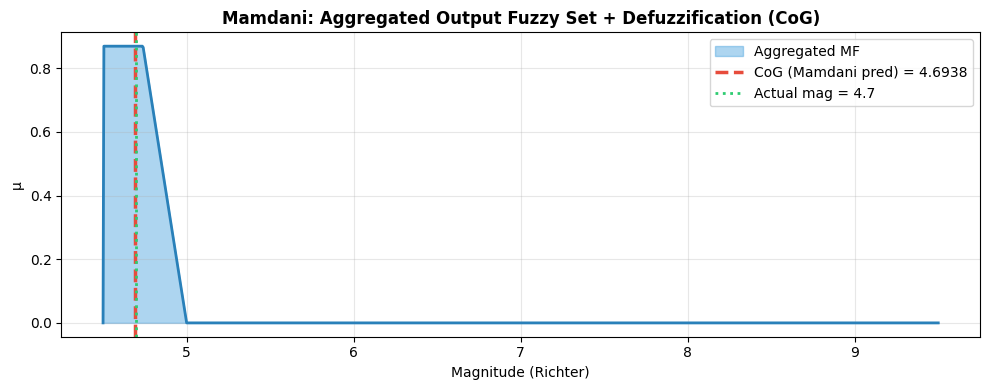

Mamdani CoG prediction: 4.6938
Actual magnitude:       4.7


In [5]:
import numpy as np
import matplotlib.pyplot as plt

activated = mamdani_inference(fuzzy_in)
z_min, z_max = 4.5, 9.5
z_pts = list(np.linspace(z_min, z_max, 1000))
agg   = mamdani_aggregate(activated, z_pts)
cog   = defuzzify_mamdani_cog(activated)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(z_pts, agg, alpha=0.4, color='#3498db', label='Aggregated MF')
ax.plot(z_pts, agg, color='#2980b9', linewidth=2)
ax.axvline(cog, color='#e74c3c', linewidth=2.5, linestyle='--',
           label=f'CoG (Mamdani pred) = {cog:.4f}')
if example_row.get('mag'):
    ax.axvline(float(example_row['mag']), color='#2ecc71', linewidth=2,
               linestyle=':', label=f'Actual mag = {example_row["mag"]}')
ax.set_xlabel('Magnitude (Richter)')
ax.set_ylabel('μ')
ax.set_title('Mamdani: Aggregated Output Fuzzy Set + Defuzzification (CoG)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mamdani_output.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mamdani CoG prediction: {cog:.4f}')
print(f'Actual magnitude:       {example_row["mag"]}')

---
## Cell 6 – Sugeno: weighted average

In [6]:
sugeno_out = sugeno_inference(fuzzy_in)
sugeno_pred = defuzzify_sugeno_weighted_avg(sugeno_out)

print('=== SUGENO INFERENCE ===')
print(f'{"Rule weight w":>16}  {"Consequent k":>14}  {"w × k":>10}')
print('-' * 46)
for w, k in sugeno_out:
    print(f'{w:>16.4f}  {k:>14.2f}  {w*k:>10.4f}')
print('-' * 46)
total_w  = sum(w for w, _ in sugeno_out)
total_wk = sum(w * k for w, k in sugeno_out)
print(f'{total_w:>16.4f}  {"":>14}  {total_wk:>10.4f}')
print(f'\nWeighted Average = {total_wk:.4f} / {total_w:.4f} = {sugeno_pred:.4f}')
print(f'Actual magnitude = {example_row["mag"]}')

=== SUGENO INFERENCE ===
   Rule weight w    Consequent k       w × k
----------------------------------------------
          0.8696            4.65      4.0435
----------------------------------------------
          0.8696                      4.0435

Weighted Average = 4.0435 / 0.8696 = 4.6500
Actual magnitude = 4.7


---
## Cell 7 – Full end-to-end predict() on one row

In [7]:
result = predict(example_row)

print('=== PREDICT() RESULT ===')
print(f'  Mamdani (CoG)          : {result["mamdani_pred"]:.4f}')
print(f'  Sugeno  (Weighted Avg) : {result["sugeno_pred"]:.4f}')
print(f'  Actual magnitude       : {result["actual_mag"]:.4f}')
print(f'  Mamdani absolute error : {abs(result["actual_mag"] - result["mamdani_pred"]):.4f}')
print(f'  Sugeno  absolute error : {abs(result["actual_mag"] - result["sugeno_pred"]):.4f}')

=== PREDICT() RESULT ===
  Mamdani (CoG)          : 4.6938
  Sugeno  (Weighted Avg) : 4.6500
  Actual magnitude       : 4.7000
  Mamdani absolute error : 0.0062
  Sugeno  absolute error : 0.0500


---
## Cell 8 – Test multiple hand-crafted rows

In [8]:
test_cases = [
    # Description,           lat,    lon,    depth, gap,   rms,  actual
    ('Central-shallow-good', 37.36, 142.45,  35.0, 112.7,  0.85, 4.7),
    ('Northern-deep-poor',   49.0,  155.0,   400,  210.0,  1.5,  5.2),
    ('North arc shallow M7', 49.3,  156.3,   10.0, 200.0,  1.4,  6.5),
    ('Southern shallow',     26.5,  129.5,   10.0,  85.0,  0.7,  4.6),
    ('Central deep good',    40.0,  142.0,  450.0,  70.0,  0.6,  4.8),
    ('North intermediate',   45.0,  150.0,  120.0, 105.0,  0.88, 5.0),
]

print(f'  {"Description":<25} {"Actual":>7} {"Mamdani":>9} {"Sugeno":>9} {"Err(M)":>8} {"Err(S)":>8}')
print('  ' + '-' * 72)

for desc, lat, lon, dep, gap, rms, actual in test_cases:
    row = {'latitude': lat, 'longitude': lon, 'depth': dep,
           'gap': gap, 'rms': rms, 'mag': actual}
    r = predict(row)
    em = abs(actual - r['mamdani_pred'])
    es = abs(actual - r['sugeno_pred'])
    print(f'  {desc:<25} {actual:>7.2f} {r["mamdani_pred"]:>9.4f} {r["sugeno_pred"]:>9.4f} {em:>8.4f} {es:>8.4f}')

  Description                Actual   Mamdani    Sugeno   Err(M)   Err(S)
  ------------------------------------------------------------------------
  Central-shallow-good         4.70    4.6938    4.6500   0.0062   0.0500
  Northern-deep-poor           5.20    6.1333    6.0000   0.9333   0.8000
  North arc shallow M7         6.50    8.2346    7.8000   1.7346   1.3000
  Southern shallow             4.60    4.7390    4.6500   0.1390   0.0500
  Central deep good            4.80    5.1881    5.0000   0.3881   0.2000
  North intermediate           5.00    5.8625    5.8625   0.8625   0.8625


---
## Cell 9 – Batch evaluation on first 500 rows of the clean CSV

In [9]:
metrics_500 = evaluate_all(max_rows=500, verbose=False)

print('=== BATCH METRICS (first 500 rows) ===')
for method in ('mamdani', 'sugeno'):
    m = metrics_500[method]
    label = 'Mamdani (CoG)' if method == 'mamdani' else 'Sugeno  (WA) '
    print(f'\n  {label}:')
    print(f'    n    = {m["n"]}')
    print(f'    MAE  = {m["MAE"]:.4f}')
    print(f'    MSE  = {m["MSE"]:.4f}')
    print(f'    RMSE = {m["RMSE"]:.4f}')

=== BATCH METRICS (first 500 rows) ===

  Mamdani (CoG):
    n    = 500
    MAE  = 0.7755
    MSE  = 0.9522
    RMSE = 0.9758

  Sugeno  (WA) :
    n    = 500
    MAE  = 0.6891
    MSE  = 0.8061
    RMSE = 0.8978


---
## Cell 10 – Full dataset evaluation (all 13,233 rows)

In [10]:
print('Running full evaluation on 13,233 rows (may take ~30 s) ...')
full = evaluate_all(verbose=False)

print('\n=== FULL DATASET METRICS ===')
for method in ('mamdani', 'sugeno'):
    m = full[method]
    label = 'Mamdani (CoG)' if method == 'mamdani' else 'Sugeno  (WA) '
    print(f'\n  {label}:')
    print(f'    n    = {m["n"]:,}')
    print(f'    MAE  = {m["MAE"]:.6f}')
    print(f'    MSE  = {m["MSE"]:.6f}')
    print(f'    RMSE = {m["RMSE"]:.6f}')

Running full evaluation on 13,233 rows (may take ~30 s) ...

=== FULL DATASET METRICS ===

  Mamdani (CoG):
    n    = 13,233
    MAE  = 0.752175
    MSE  = 1.002956
    RMSE = 1.001477

  Sugeno  (WA) :
    n    = 13,233
    MAE  = 0.674465
    MSE  = 0.842995
    RMSE = 0.918148


---
## Cell 11 – Visualise: Predicted vs Actual for 500 rows

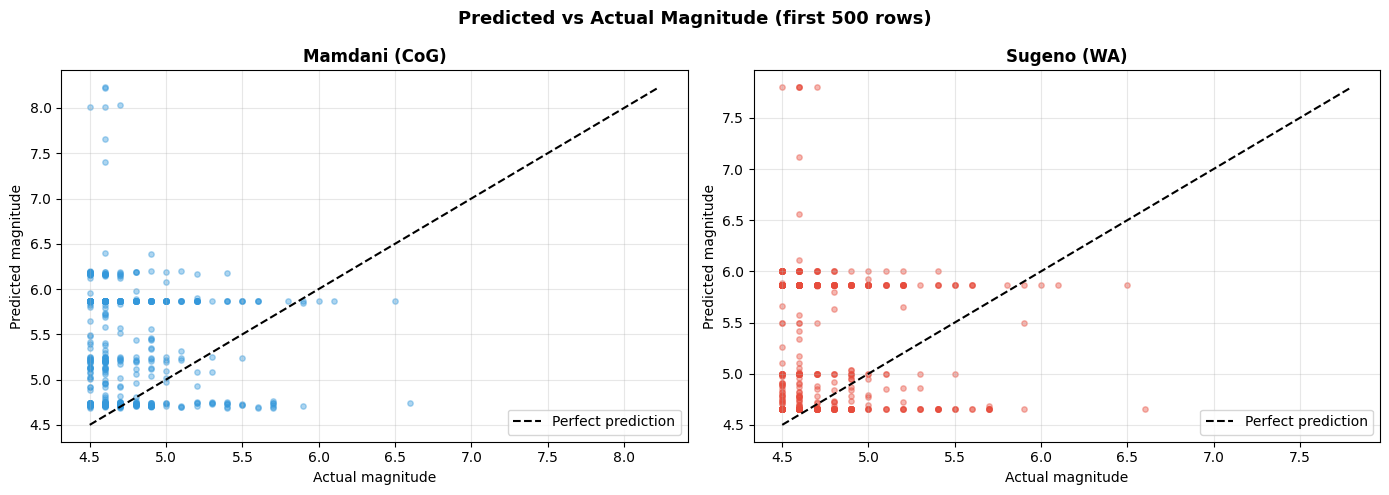

In [11]:
import csv
import matplotlib.pyplot as plt

actuals, m_preds, s_preds = [], [], []
with open(CLEAN_CSV, newline='', encoding='utf-8') as f:
    for i, row in enumerate(csv.DictReader(f)):
        if i >= 500:
            break
        r = predict(row)
        actuals.append(r['actual_mag'])
        m_preds.append(r['mamdani_pred'])
        s_preds.append(r['sugeno_pred'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Predicted vs Actual Magnitude (first 500 rows)', fontsize=13, fontweight='bold')

for ax, preds, label, color in [
    (axes[0], m_preds, 'Mamdani (CoG)', '#3498db'),
    (axes[1], s_preds, 'Sugeno (WA)',   '#e74c3c'),
]:
    ax.scatter(actuals, preds, alpha=0.4, s=15, color=color)
    lo = min(min(actuals), min(preds))
    hi = max(max(actuals), max(preds))
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual magnitude')
    ax.set_ylabel('Predicted magnitude')
    ax.set_title(label, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 12 – Error distribution histogram

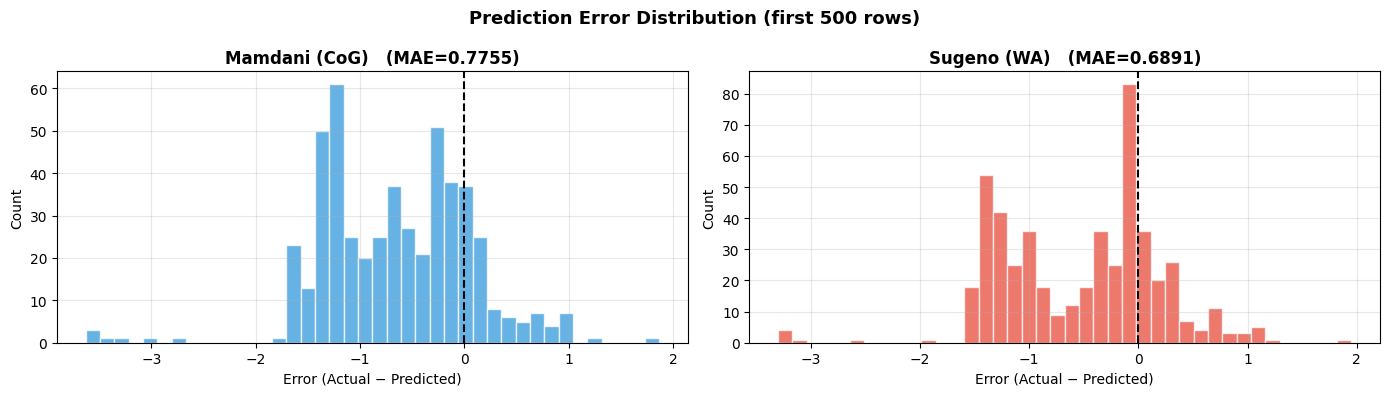

In [12]:
import matplotlib.pyplot as plt

m_errors = [a - p for a, p in zip(actuals, m_preds)]
s_errors = [a - p for a, p in zip(actuals, s_preds)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Prediction Error Distribution (first 500 rows)', fontsize=13, fontweight='bold')

for ax, errors, label, color in [
    (axes[0], m_errors, 'Mamdani (CoG)', '#3498db'),
    (axes[1], s_errors, 'Sugeno (WA)',   '#e74c3c'),
]:
    ax.hist(errors, bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    mae = sum(abs(e) for e in errors) / len(errors)
    ax.set_title(f'{label}   (MAE={mae:.4f})', fontweight='bold')
    ax.set_xlabel('Error (Actual − Predicted)')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_hist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 13 – Interactive tester: enter your own values

In [13]:
# ── Change these values to test any earthquake scenario ──
MY_LAT  = 37.36   # latitude  (23 – 51 °N)
MY_LON  = 142.45  # longitude (124 – 159 °E)
MY_DEP  = 35.0    # depth     (0 – 700 km)
MY_GAP  = 112.7   # gap       (0 – 310 °)
MY_RMS  = 0.85    # rms       (0.1 – 1.9 s)

# ─────────────────────────────────────────────────────────
custom_row = {
    'latitude':  MY_LAT,
    'longitude': MY_LON,
    'depth':     MY_DEP,
    'gap':       MY_GAP,
    'rms':       MY_RMS,
}

result = predict(custom_row)
fi     = result['fuzzy_inputs']

print('=== YOUR INPUT ===')
for k, v in custom_row.items():
    print(f'  {k:<12}: {v}')

print('\n=== FUZZIFICATION ===')
for var, memberships in fi.items():
    parts = ', '.join(f'{s}={m:.3f}' for s, m in memberships.items())
    print(f'  {var:<12}: {parts}')

print('\n=== PREDICTION ===')
print(f'  Mamdani (CoG)          : {result["mamdani_pred"]:.4f}')
print(f'  Sugeno  (Weighted Avg) : {result["sugeno_pred"]:.4f}')

=== YOUR INPUT ===
  latitude    : 37.36
  longitude   : 142.45
  depth       : 35.0
  gap         : 112.7
  rms         : 0.85

=== FUZZIFICATION ===
  latitude    : South=0.000, Central=0.949, North=0.000
  longitude   : West=0.000, Central=0.955, East=0.000
  depth       : Shallow=1.000, Intermediate=0.000, Deep=0.000
  gap         : WellCovered=0.000, Moderate=0.946, PoorlyCovered=0.000
  rms         : HighQuality=0.000, Moderate=0.870, LowQuality=0.000

=== PREDICTION ===
  Mamdani (CoG)          : 4.6938
  Sugeno  (Weighted Avg) : 4.6500


---
## Cell 14 – Mamdani vs Sugeno comparison bar chart

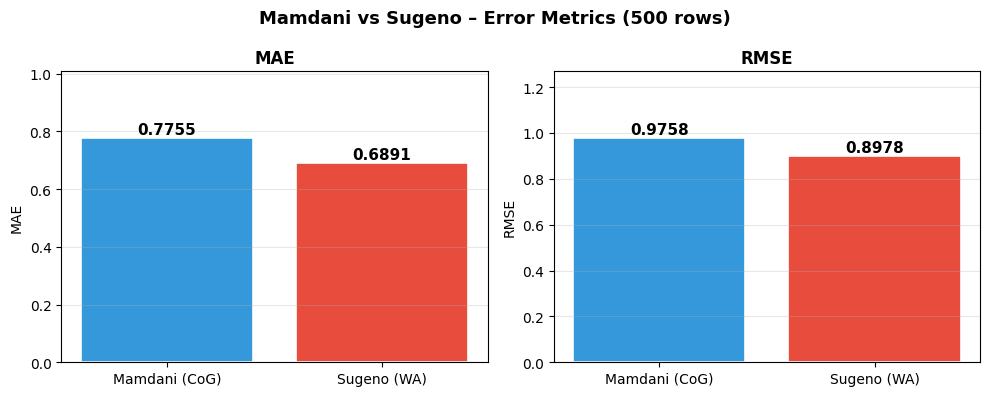


Conclusion:
  Lower MAE  → Sugeno
  Lower RMSE → Sugeno


In [14]:
import matplotlib.pyplot as plt

methods = ['Mamdani (CoG)', 'Sugeno (WA)']
mae_vals  = [metrics_500['mamdani']['MAE'],  metrics_500['sugeno']['MAE']]
rmse_vals = [metrics_500['mamdani']['RMSE'], metrics_500['sugeno']['RMSE']]

x = range(len(methods))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Mamdani vs Sugeno – Error Metrics (500 rows)', fontsize=13, fontweight='bold')

colors = ['#3498db', '#e74c3c']
for ax, vals, metric in [(axes[0], mae_vals, 'MAE'), (axes[1], rmse_vals, 'RMSE')]:
    bars = ax.bar(methods, vals, color=colors, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nConclusion:')
winner_mae  = 'Mamdani' if mae_vals[0]  < mae_vals[1]  else 'Sugeno'
winner_rmse = 'Mamdani' if rmse_vals[0] < rmse_vals[1] else 'Sugeno'
print(f'  Lower MAE  → {winner_mae}')
print(f'  Lower RMSE → {winner_rmse}')